# Procesador de Datos CONCYTEC (CTIVitae)
## Instrucciones de Operación

1. Descargar la plantilla(en la interfaz o por medio del enlace adjunto).
https://docs.google.com/spreadsheets/d/1rLKLY4_rKoT-HVT_t3XXMO4J67zCJsLQ/export?format=xlsx
2. Subir la plantilla rellenada en los campos resaltados.
3. Ingresar el valor del JSESSIONID en el campo correspondiente y confirmar mediante el botón Actualizar Cookie.
4. Ejecutar secuencialmente los pasos. Luego del paso 2 se recomienda realizar una revisión manual para eliminar resultados múltiples.
5. La revisión manual y descarga del excel procesado se puede realizar mediante el botón verde en la interfaz luego de cualquier intereacción.
6. En caso resulte sin coincidencias la búsqueda, puede ingresar el campo de DNI en la hoja del excel "Resultados_busqueda". Luego buscar con el [3] Consultar por DNI.
7. Ejecutar pasos del 4 al 5.
8. Monitorear el progreso a través de la consola de salida integrada en la interfaz.

Ejemplos de como ingresar los datos

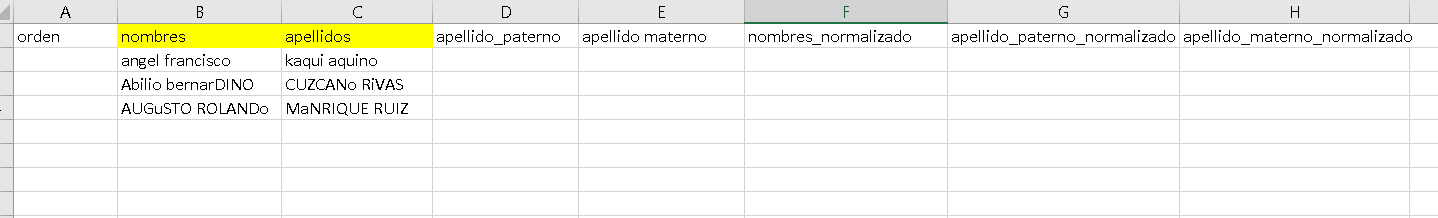

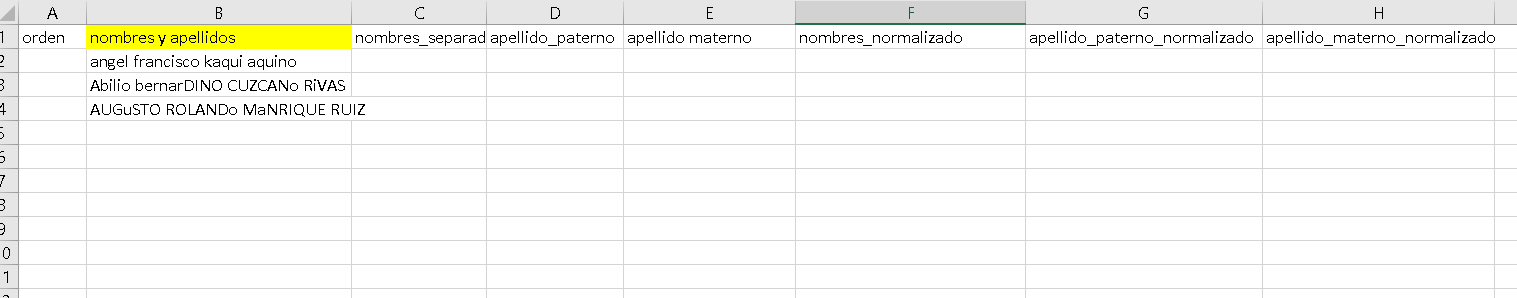

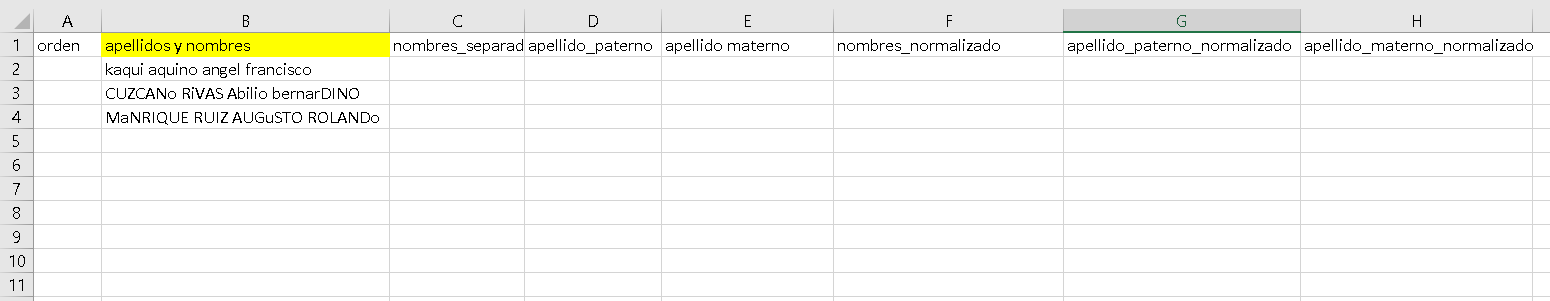

Ejemplos de consultar por DNI

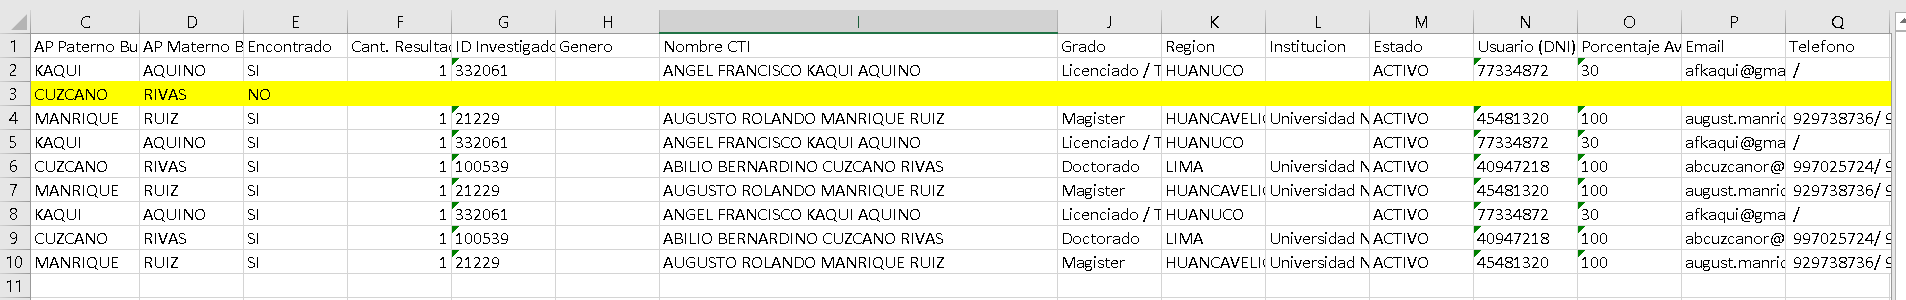

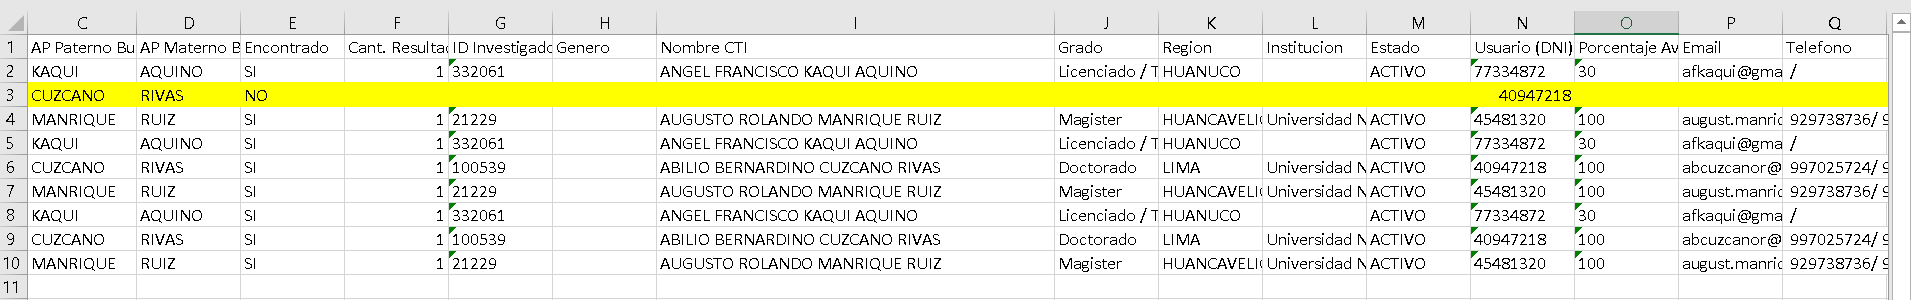

## Configuraciones

###Instalaciones

In [ ]:
!pip install pdfplumber

   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/914.9 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/914.9 kB ? eta -:--:--
   --------------------- ---------------- 524.3/914.9 kB 950.0 kB/s eta 0:00:01
   --------------------- ---------------- 524.3/914.9 kB 950.0 kB/s eta 0:00:01
   --------------------- ---------------- 524.3/914.9 kB 950.0 kB/s eta 0:00:01
   -------------------------------- ----- 786.4/914.9 kB 629.3 kB/s eta 0:00:01
   ---------------------------------------- 914.9/914.9 kB 565.4 kB/s  0:00:01
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.2 MB ? eta -:--:--
   ---- ---------------------------------

###Funciones

In [6]:
import ipywidgets as widgets
from IPython.display import display, clear_output, Javascript, HTML as IHTML
import time
import os

# =============================================================================
# StepLogger + StepTracker  (widgets.HTML + .value update + flush)
# =============================================================================
class StepLogger:
    def __init__(self, output_widget):
        self.output = output_widget
        self._steps = []

    def create_step(self, title, total=0):
        return StepTracker(title, total, self.output, self)

    def _register_summary(self, html_widget):
        self._steps.append(html_widget)


class StepTracker:
    def __init__(self, title, total, output, logger):
        self.title = title
        self.total = total
        self.output = output
        self.logger = logger
        self.current = 0
        self.start_time = time.time()
        self.details = []
        self.incidents = []
        self.counters = {}

        # Widget HTML unico para la barra en vivo
        self._bar = widgets.HTML(value=self._render_live())
        with self.output:
            display(self._bar)
        time.sleep(0.05)

    def _render_live(self):
        pct = (self.current / max(self.total, 1)) * 100 if self.total > 0 else 0
        elapsed = time.time() - self.start_time
        if self.total > 0 and self.current > 0:
            per_item = elapsed / self.current
            remaining = per_item * (self.total - self.current)
            eta = f"ETA: {self._fmt(remaining)}"
        else:
            eta = ""
        restantes = self.total - self.current
        last_label = self.details[-1][0] if self.details else ""

        html = (
            '<div style="font-family:Consolas,monospace; background:#fff; '
            'padding:10px 12px; border:1px solid #dee2e6; border-radius:4px; '
            'margin-top:6px; color:#212529;">'
            '<div style="font-size:13px; font-weight:bold; color:#1a1a2e; '
            'padding-bottom:6px; border-bottom:2px solid #1565c0; '
            f'margin-bottom:8px;">{self.title}</div>'
        )

        if self.total > 0:
            html += (
                '<div style="background:#e9ecef; border-radius:4px; height:20px; '
                'width:100%; margin-bottom:4px; overflow:hidden;">'
                f'<div style="background:#1565c0; height:100%; width:{pct:.1f}%; '
                'border-radius:4px; transition:width 0.3s;"></div></div>'
                f'<div style="font-size:11px; color:#555; margin-bottom:4px;">'
                f'{self.current}/{self.total} ({pct:.0f}%) &nbsp;&nbsp; {eta}</div>'
            )
            if restantes > 0 and last_label:
                html += (
                    '<div style="font-size:11px; color:#333; padding:2px 0;">'
                    f'Procesando: <b>{last_label}</b> &nbsp;|&nbsp; '
                    f'Pendientes: {restantes}</div>'
                )
            elif self.current > 0 and restantes == 0:
                html += (
                    '<div style="font-size:11px; color:#0d7c3b; padding:2px 0;">'
                    f'Finalizado en {self._fmt(elapsed)}</div>'
                )

        html += '</div>'
        return html

    def _fmt(self, seconds):
        if seconds < 60:
            return f"{seconds:.0f}s"
        m, s = divmod(int(seconds), 60)
        return f"{m}m {s:02d}s"

    def advance(self, label, status="OK", info=""):
        self.current += 1
        self.details.append((label, status, info))
        self.counters[status] = self.counters.get(status, 0) + 1
        self._bar.value = self._render_live()
        # Micro-pausa para que Colab procese la actualizacion del widget
        time.sleep(0.05)

    def incident(self, message):
        self.incidents.append(message)

    def log_message(self, message):
        with self.output:
            display(IHTML(
                f'<div style="font-family:Consolas,monospace; font-size:12px; '
                f'color:#555; padding:2px 12px; background:#fff;">{message}</div>'
            ))

    def finish(self, summary_lines=None, show_detail=True):
        elapsed = time.time() - self.start_time
        elapsed_str = self._fmt(elapsed)

        # Ocultar la barra en vivo (valor vacio + display none)
        self._bar.value = ""
        self._bar.layout.display = "none"

        # --- Resumen ---
        if summary_lines is None:
            summary_lines = self.counters.copy()

        summary_rows = ""
        for k, v in summary_lines.items():
            summary_rows += (
                f'<tr><td style="padding:3px 16px 3px 0; color:#555;">{k}</td>'
                f'<td style="padding:3px 0; font-weight:500; color:#212529;">{v}</td></tr>'
            )

        status_color = "#0d7c3b" if not self.incidents else "#c0392b"
        status_text = "COMPLETADO" if not self.incidents else f"COMPLETADO CON {len(self.incidents)} INCIDENCIA(S)"

        summary_html = (
            '<div style="font-family:Consolas,monospace; font-size:12px; '
            'background:#f8f9fa; border:1px solid #dee2e6; border-radius:4px; '
            'padding:10px 14px; margin:4px 0; color:#212529;">'
            f'<div style="font-size:13px; font-weight:bold; color:#1a1a2e; margin-bottom:6px;">{self.title}</div>'
            '<table style="border-collapse:collapse;">'
            f'<tr><td style="padding:3px 16px 3px 0; color:#555;">Estado</td>'
            f'<td style="padding:3px 0; font-weight:600; color:{status_color};">{status_text}</td></tr>'
            f'<tr><td style="padding:3px 16px 3px 0; color:#555;">Tiempo</td>'
            f'<td style="padding:3px 0; color:#212529;">{elapsed_str}</td></tr>'
            f'{summary_rows}'
            '</table></div>'
        )

        summary_widget = widgets.HTML(value=summary_html)
        with self.output:
            display(summary_widget)

        # --- Detalle expandible ---
        if show_detail and self.details:
            detail_rows = ""
            for i, (label, status, info) in enumerate(self.details, 1):
                if status == "OK":
                    st_style = "color:#0d7c3b;"
                elif status == "SIN RESULTADO":
                    st_style = "color:#6c757d;"
                elif status == "MULTIPLE":
                    st_style = "color:#e67e22;"
                elif status == "ERROR":
                    st_style = "color:#c0392b; font-weight:600;"
                else:
                    st_style = "color:#212529;"
                info_text = f' -- {info}' if info else ''
                detail_rows += (
                    f'<tr style="border-bottom:1px solid #dee2e6;">'
                    f'<td style="padding:3px 10px; text-align:right; color:#6c757d;">{i}</td>'
                    f'<td style="padding:3px 10px; color:#212529;">{label}</td>'
                    f'<td style="padding:3px 10px; {st_style}">{status}{info_text}</td>'
                    '</tr>'
                )

            detail_html = (
                '<div style="font-family:Consolas,monospace; font-size:11px; '
                'max-height:300px; overflow-y:auto; color:#212529; background:#fff;">'
                '<table style="width:100%; border-collapse:collapse;">'
                '<tr style="background:#e9ecef; font-weight:600; color:#212529;">'
                '<td style="padding:4px 10px; width:40px;">Nro</td>'
                '<td style="padding:4px 10px;">Nombre</td>'
                '<td style="padding:4px 10px;">Resultado</td></tr>'
                f'{detail_rows}</table></div>'
            )

            accordion = widgets.Accordion(
                children=[widgets.HTML(value=detail_html)],
                selected_index=None
            )
            accordion.set_title(0, f"Ver detalle ({len(self.details)} registros)")
            with self.output:
                display(accordion)

        # --- Incidencias ---
        if self.incidents:
            inc_rows = "".join(
                f'<div style="padding:2px 0;">{inc}</div>'
                for inc in self.incidents
            )
            inc_html = (
                '<div style="font-family:Consolas,monospace; font-size:11px; '
                'background:#fff3cd; border:1px solid #ffc107; border-radius:4px; '
                'padding:8px 12px; margin:4px 0; color:#856404;">'
                '<div style="font-weight:600; margin-bottom:4px;">Incidencias</div>'
                f'{inc_rows}</div>'
            )
            with self.output:
                display(widgets.HTML(value=inc_html))

        self.logger._register_summary(summary_widget)


# =============================================================================
# UI
# =============================================================================
cookie_input = widgets.Text(
    value='',
    placeholder='Pegue su JSESSIONID aqui',
    description='JSESSIONID:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='70%')
)
btn_save_cookie = widgets.Button(description="Actualizar Cookie", button_style='info')

file_upload = widgets.FileUpload(
    accept='.xlsx,.xls',
    multiple=False,
    description='Subir Excel:',
    button_style='warning'
)
btn_download_excel = widgets.Button(description="Descargar Excel Procesado", button_style='success')

btn_template_link = widgets.Button(description="Descargar Plantilla", button_style='primary', icon='download')
TEMPLATE_URL = "https://docs.google.com/spreadsheets/d/1rLKLY4_rKoT-HVT_t3XXMO4J67zCJsLQ/export?format=xlsx"

current_excel_path = '/content/Procesador_datos.xlsx'

btns_processing = [
    widgets.Button(description="[1] Normalizar Nombres"),
    widgets.Button(description="[2] Consultar API"),
    widgets.Button(description="[3] Consultar por DNI"),
    widgets.Button(description="[4] Completar PDF"),
    widgets.Button(description="[5] Verificar Datos")
]

console_output = widgets.Output(
    layout=widgets.Layout(
        border='1px solid #dee2e6',
        height='420px',
        overflow_y='auto',
        padding='8px'
    )
)

step_logger = StepLogger(console_output)

def log(message):
    with console_output:
        display(IHTML(
            f'<div style="font-family:Consolas,monospace; font-size:12px; '
            f'color:#555; padding:2px 0; background:#fff;">'
            f'[{time.strftime("%H:%M:%S")}] {message}</div>'
        ))

def on_save_cookie(b):
    log(f"Cookie registrada: {cookie_input.value[:15]}...")

def on_file_upload(change):
    try:
        if not file_upload.value:
            return
        uploaded_file = list(file_upload.value.values())[0]
        with open(current_excel_path, 'wb') as f:
            f.write(uploaded_file['content'])
        log(f"Archivo subido exitosamente como 'Procesador_datos.xlsx'")
    except Exception as e:
        log(f"Error subiendo archivo: {str(e)}")

def on_download_excel(b):
    if os.path.exists(current_excel_path):
        from google.colab import files
        files.download(current_excel_path)
        log("Iniciando descarga del archivo procesado...")
    else:
        log("ERROR: No hay archivo procesado para descargar.")

def on_click_template_link(b):
    log("Abriendo enlace de descarga de plantilla...")
    display(Javascript(f"window.open('{TEMPLATE_URL}');"))

btn_save_cookie.on_click(on_save_cookie)
btn_download_excel.on_click(on_download_excel)
btn_template_link.on_click(on_click_template_link)
file_upload.observe(on_file_upload, names='value')

section_style = 'font-family:Arial,sans-serif; font-size:13px; font-weight:600; color:#1565c0; padding:8px 0 2px;'

header = widgets.HTML(
    '<div style="font-family:Arial,sans-serif; font-size:18px; font-weight:700; '
    'color:#1a1a2e; padding:10px 0; border-bottom:3px solid #1565c0; '
    'background:#fff;">'
    'Procesador de Datos CONCYTEC</div>'
)

ui = widgets.VBox([
    header,
    widgets.HTML(f'<div style="{section_style}">1. Configuracion de sesion</div>'),
    widgets.HBox([cookie_input, btn_save_cookie]),
    widgets.HTML(f'<div style="{section_style}">2. Carga de archivo</div>'),
    widgets.HBox([file_upload, btn_template_link, btn_download_excel]),
    widgets.HTML(f'<div style="{section_style}">3. Flujo de trabajo</div>'),
    widgets.VBox([
        widgets.HBox(btns_processing[0:2]),
        widgets.HBox(btns_processing[2:4]),
        btns_processing[4]
    ]),
    widgets.HTML(f'<div style="{section_style}">Consola</div>'),
    console_output
])

clear_output()

In [ ]:
import unicodedata
import openpyxl
import os

def data_path(filename):
    return os.path.join('/content', filename)

def normalizar(texto):
    """Convierte a mayusculas y elimina tildes/caracteres especiales."""
    if not texto:
        return ""
    texto = str(texto).strip().upper()
    texto = unicodedata.normalize("NFD", texto)
    texto = "".join(c for c in texto if unicodedata.category(c) != "Mn")
    texto = "".join(c if c.isalnum() or c == " " else " " for c in texto)
    texto = " ".join(texto.split())
    return texto

def separar_apellidos(texto_apellidos):
    """Separa apellidos: primera palabra = paterno, resto = materno."""
    partes = str(texto_apellidos).strip().split()
    ap_pat = partes[0] if len(partes) >= 1 else ""
    ap_mat = " ".join(partes[1:]) if len(partes) >= 2 else ""
    return ap_pat, ap_mat

def parsear_nombres_apellidos_juntos(texto):
    """
    Hoja: Entrada_nombres_apellido_juntos (NOMBRES primero, APELLIDOS despues)
    Con coma: 'JULIO ARNALDO, ACOSTA SULLCAHUAMAN'
    Sin coma: 'JULIO ARNALDO ACOSTA SULLCAHUAMAN' (ultimas 2 palabras = apellidos)
    """
    texto = str(texto).strip()
    if "," in texto:
        partes_coma = [p.strip() for p in texto.split(",", 1)]
        nombres_raw = partes_coma[0]
        apellidos_raw = partes_coma[1] if len(partes_coma) > 1 else ""
        ap_pat, ap_mat = separar_apellidos(apellidos_raw)
        return nombres_raw, ap_pat, ap_mat
    partes = texto.split()
    if len(partes) >= 3:
        return " ".join(partes[:-2]), partes[-2], partes[-1]
    elif len(partes) == 2:
        return partes[0], partes[1], ""
    else:
        return partes[0] if partes else "", "", ""

def parsear_apellidos_nombres_juntos(texto):
    """
    Hoja: Entrada_ap_nombres_juntos (APELLIDOS primero, NOMBRES despues)
    Con coma: 'ACOSTA SULLCAHUAMAN, JULIO ARNALDO'
    Sin coma: 'ACOSTA SULLCAHUAMAN JULIO ARNALDO' (primeras 2 palabras = apellidos)
    """
    texto = str(texto).strip()
    if "," in texto:
        partes_coma = [p.strip() for p in texto.split(",", 1)]
        apellidos_raw = partes_coma[0]
        nombres_raw = partes_coma[1] if len(partes_coma) > 1 else ""
        ap_pat, ap_mat = separar_apellidos(apellidos_raw)
        return ap_pat, ap_mat, nombres_raw
    partes = texto.split()
    if len(partes) >= 3:
        return partes[0], partes[1], " ".join(partes[2:])
    elif len(partes) == 2:
        return partes[0], partes[1], ""
    else:
        return partes[0] if partes else "", "", ""

def asignar_orden_correlativo(wb):
    """Asigna un ID incremental unico a traves de las 3 hojas de entrada."""
    hojas = ["Entrada_ap_nombre_separados", "Entrada_nombres_apellido_juntos", "Entrada_ap_nombres_juntos"]
    contador = 1
    for nombre_hoja in hojas:
        if nombre_hoja in wb.sheetnames:
            ws = wb[nombre_hoja]
            for r in range(2, ws.max_row + 1):
                val_b = ws.cell(r, 2).value
                if val_b and str(val_b).strip():
                    ws.cell(r, 1).value = contador
                    contador += 1
                else:
                    break
    return wb

def ejecutar_normalizacion_local():
    EXCEL = data_path("Procesador_datos.xlsx")
    if not os.path.exists(EXCEL):
        log(f"ERROR: No se encuentra el archivo {EXCEL}.")
        return

    try:
        wb = openpyxl.load_workbook(EXCEL, keep_vba=False)

        # Contar filas totales
        total_filas = 0
        hojas_info = {}
        for nombre in ["Entrada_ap_nombre_separados", "Entrada_nombres_apellido_juntos", "Entrada_ap_nombres_juntos"]:
            if nombre in wb.sheetnames:
                ws = wb[nombre]
                count = 0
                for r in range(2, ws.max_row + 1):
                    if ws.cell(r, 2).value and str(ws.cell(r, 2).value).strip():
                        count += 1
                    else:
                        break
                hojas_info[nombre] = count
                total_filas += count

        step = step_logger.create_step("PASO 1: Normalizacion de nombres", total_filas)

        # Asignar orden correlativo
        wb = asignar_orden_correlativo(wb)

        stats = {"con_coma": 0, "sin_coma": 0}

        # Hoja 1: Entrada_ap_nombre_separados
        if "Entrada_ap_nombre_separados" in wb.sheetnames:
            ws = wb["Entrada_ap_nombre_separados"]
            for r in range(2, ws.max_row + 1):
                nombres = ws.cell(r, 2).value
                apellidos = ws.cell(r, 3).value
                if not nombres and not apellidos: break
                ap_paterno, ap_materno = separar_apellidos(apellidos or "")
                ws.cell(r, 4).value = ap_paterno
                ws.cell(r, 5).value = ap_materno
                ws.cell(r, 6).value = normalizar(nombres)
                ws.cell(r, 7).value = normalizar(ap_paterno)
                ws.cell(r, 8).value = normalizar(ap_materno)
                label = f"{normalizar(nombres)} {normalizar(ap_paterno)}"
                step.advance(label, "OK")

        # Hoja 2: Entrada_nombres_apellido_juntos
        if "Entrada_nombres_apellido_juntos" in wb.sheetnames:
            ws = wb["Entrada_nombres_apellido_juntos"]
            for r in range(2, ws.max_row + 1):
                completo = ws.cell(r, 2).value
                if not completo: break
                texto = str(completo)
                nombres, ap_paterno, ap_materno = parsear_nombres_apellidos_juntos(texto)
                if "," in texto:
                    stats["con_coma"] += 1
                else:
                    stats["sin_coma"] += 1
                ws.cell(r, 3).value = nombres
                ws.cell(r, 4).value = ap_paterno
                ws.cell(r, 5).value = ap_materno
                ws.cell(r, 6).value = normalizar(nombres)
                ws.cell(r, 7).value = normalizar(ap_paterno)
                ws.cell(r, 8).value = normalizar(ap_materno)
                label = f"{normalizar(nombres)} {normalizar(ap_paterno)}"
                step.advance(label, "OK")

        # Hoja 3: Entrada_ap_nombres_juntos
        if "Entrada_ap_nombres_juntos" in wb.sheetnames:
            ws = wb["Entrada_ap_nombres_juntos"]
            for r in range(2, ws.max_row + 1):
                completo = ws.cell(r, 2).value
                if not completo: break
                texto = str(completo)
                ap_paterno, ap_materno, nombres = parsear_apellidos_nombres_juntos(texto)
                if "," in texto:
                    stats["con_coma"] += 1
                else:
                    stats["sin_coma"] += 1
                ws.cell(r, 3).value = nombres
                ws.cell(r, 4).value = ap_paterno
                ws.cell(r, 5).value = ap_materno
                ws.cell(r, 6).value = normalizar(nombres)
                ws.cell(r, 7).value = normalizar(ap_paterno)
                ws.cell(r, 8).value = normalizar(ap_materno)
                label = f"{normalizar(ap_paterno)} {normalizar(nombres)}"
                step.advance(label, "OK")

        wb.save(EXCEL)

        summary = {"Procesados": f"{total_filas}"}
        for nombre, count in hojas_info.items():
            short = nombre.replace("Entrada_", "")
            summary[short] = f"{count} filas"
        if stats["con_coma"] or stats["sin_coma"]:
            summary["Formato con coma"] = stats["con_coma"]
            summary["Formato sin coma"] = stats["sin_coma"]

        step.finish(summary_lines=summary, show_detail=False)

    except Exception as e:
        log(f"Error: {str(e)}")

Actualizamos la lógica de los botones para que el primer botón llame a la función de normalización real.

In [ ]:
import requests
from bs4 import BeautifulSoup
import time
import openpyxl
import os

def ejecutar_consulta_api_local():
    EXCEL = "/content/Procesador_datos.xlsx"
    mi_jsessionid = cookie_input.value.strip()

    if not mi_jsessionid:
        log("ERROR: Ingrese el JSESSIONID en el campo de configuracion.")
        return
    if not os.path.exists(EXCEL):
        log(f"ERROR: No se encuentra el archivo {EXCEL}.")
        return

    try:
        wb = openpyxl.load_workbook(EXCEL)

        # Recolectar personas de las 3 hojas
        personas = []
        hojas_entrada = ["Entrada_ap_nombre_separados", "Entrada_nombres_apellido_juntos", "Entrada_ap_nombres_juntos"]
        for nombre_hoja in hojas_entrada:
            if nombre_hoja in wb.sheetnames:
                ws = wb[nombre_hoja]
                for r in range(2, ws.max_row + 1):
                    orden = ws.cell(r, 1).value
                    nombres = ws.cell(r, 6).value
                    ap_pat = ws.cell(r, 7).value
                    ap_mat = ws.cell(r, 8).value
                    if nombres or ap_pat:
                        personas.append({"orden": orden, "nombres": nombres, "ap_pat": ap_pat, "ap_mat": ap_mat})

        step = step_logger.create_step("PASO 2: Consulta API CTI Vitae", len(personas))

        # Preparar Resultados_busqueda
        if "Resultados_busqueda" not in wb.sheetnames:
            wb.create_sheet("Resultados_busqueda")
        ws_res = wb["Resultados_busqueda"]
        HEADERS_RES = [
            "Orden", "Nombres Buscados", "AP Paterno Buscado", "AP Materno Buscado",
            "Encontrado", "Cant. Resultados",
            "ID Investigador", "Genero", "Nombre CTI", "Grado", "Region",
            "Institucion", "Estado", "Usuario (DNI)",
            "Porcentaje Avance", "Email", "Telefono"
        ]
        for c, h in enumerate(HEADERS_RES, 1):
            ws_res.cell(1, c).value = h

        session = requests.Session()
        session.headers.update({
            "User-Agent": "Mozilla/5.0",
            "Cookie": f"JSESSIONID={mi_jsessionid}"
        })

        DELAY = 1.5
        fila_res = 2
        encontrados = 0
        sin_resultado = 0
        multiples = 0
        errores = 0

        for i, p in enumerate(personas):
            label = f"{p['nombres'] or ''} {p['ap_pat'] or ''}"
            params = {
                "tipo_form": "search_researcher",
                "apellido_paterno": p['ap_pat'],
                "apellido_materno": "",
                "nombres": p['nombres'],
                "draw": "3", "start": "0", "length": "10"
            }
            try:
                resp = session.get(
                    "https://ctivitae.concytec.gob.pe/AdminDirectorioCTI/obtenerListaGson.do",
                    params=params, timeout=15
                )
                if resp.status_code == 200:
                    data_api = resp.json().get("data", [])
                    cant = len(data_api)
                    if cant == 0:
                        ws_res.cell(fila_res, 1).value = p['orden']
                        ws_res.cell(fila_res, 2).value = p['nombres']
                        ws_res.cell(fila_res, 3).value = p['ap_pat']
                        ws_res.cell(fila_res, 4).value = p['ap_mat']
                        ws_res.cell(fila_res, 5).value = "NO"
                        ws_res.cell(fila_res, 6).value = 0
                        fila_res += 1
                        sin_resultado += 1
                        step.advance(label, "SIN RESULTADO")
                    else:
                        for entry in data_api:
                            ws_res.cell(fila_res, 1).value  = p['orden']
                            ws_res.cell(fila_res, 2).value  = p['nombres']
                            ws_res.cell(fila_res, 3).value  = p['ap_pat']
                            ws_res.cell(fila_res, 4).value  = p['ap_mat']
                            ws_res.cell(fila_res, 5).value  = "SI"
                            ws_res.cell(fila_res, 6).value  = cant
                            ws_res.cell(fila_res, 7).value  = BeautifulSoup(entry[0], "html.parser").text
                            ws_res.cell(fila_res, 8).value  = BeautifulSoup(entry[1], "html.parser").text
                            ws_res.cell(fila_res, 9).value  = BeautifulSoup(entry[2], "html.parser").text
                            ws_res.cell(fila_res, 10).value = entry[3]
                            ws_res.cell(fila_res, 11).value = entry[4]
                            ws_res.cell(fila_res, 12).value = entry[5]
                            ws_res.cell(fila_res, 13).value = entry[7]
                            ws_res.cell(fila_res, 14).value = BeautifulSoup(entry[8], "html.parser").text
                            ws_res.cell(fila_res, 15).value = entry[9]
                            ws_res.cell(fila_res, 16).value = entry[10]
                            ws_res.cell(fila_res, 17).value = entry[11]
                            fila_res += 1

                        encontrados += 1
                        if cant > 1:
                            multiples += 1
                            step.advance(label, "MULTIPLE", f"{cant} coincidencias")
                            step.incident(f"Fila {fila_res-cant}: {label} - {cant} resultados, requiere revision")
                        else:
                            step.advance(label, "OK", "1 coincidencia")
                else:
                    errores += 1
                    step.advance(label, "ERROR", f"HTTP {resp.status_code}")
                    step.incident(f"{label}: Error HTTP {resp.status_code}")
            except Exception as e:
                errores += 1
                step.advance(label, "ERROR", str(e))
                step.incident(f"{label}: {str(e)}")

            if (i+1) % 10 == 0: wb.save(EXCEL)
            time.sleep(DELAY)

        wb.save(EXCEL)
        step.finish(summary_lines={
            "Procesados": f"{len(personas)}",
            "Encontrados": f"{encontrados} ({encontrados*100//max(len(personas),1)}%)",
            "Sin resultado": str(sin_resultado),
            "Multiples (revisar)": str(multiples),
            "Errores": str(errores)
        })

    except Exception as e:
        log(f"Error General: {e}")

In [ ]:
def ejecutar_consulta_dni_local():
    EXCEL = "/content/Procesador_datos.xlsx"
    mi_jsessionid = cookie_input.value.strip()

    if not mi_jsessionid:
        log("ERROR: Ingrese el JSESSIONID en el campo de configuracion.")
        return
    if not os.path.exists(EXCEL):
        log(f"ERROR: No se encuentra el archivo {EXCEL}.")
        return

    try:
        wb = openpyxl.load_workbook(EXCEL)
        if "Resultados_busqueda" not in wb.sheetnames:
            log("ERROR: No existe la hoja 'Resultados_busqueda'. Ejecute el Paso [2] primero.")
            return

        ws = wb["Resultados_busqueda"]

        # Identificar pendientes
        pendientes = []
        for r in range(2, ws.max_row + 1):
            encontrado = str(ws.cell(r, 5).value).strip().upper()
            dni = str(ws.cell(r, 14).value).strip()
            if encontrado != "SI" and dni and dni != "None" and dni != "":
                pendientes.append((r, dni))

        step = step_logger.create_step("PASO 3: Consulta por DNI", len(pendientes))

        if not pendientes:
            step.log_message("No hay filas pendientes con DNI para re-consultar.")
            step.finish(summary_lines={"Pendientes": "0"}, show_detail=False)
            return

        session = requests.Session()
        session.headers.update({
            "User-Agent": "Mozilla/5.0",
            "Cookie": f"JSESSIONID={mi_jsessionid}"
        })

        DELAY = 2
        actualizados = 0
        no_encontrados = 0
        errores = 0

        for i, (fila, dni) in enumerate(pendientes):
            nombre = str(ws.cell(fila, 2).value or "")
            label = f"DNI {dni} ({nombre})"
            params = {
                "tipo_form": "search_researcher",
                "apellido_paterno": "", "apellido_materno": "", "nombres": "",
                "nro_doc2": dni, "tipo_doc2": "0", "id_invest": "",
                "draw": "3", "start": "0", "length": "10"
            }
            try:
                resp = session.get(
                    "https://ctivitae.concytec.gob.pe/AdminDirectorioCTI/obtenerListaGson.do",
                    params=params, timeout=20
                )
                if resp.status_code == 200:
                    data_api = resp.json().get("data", [])
                    if data_api:
                        entry = data_api[0]
                        ws.cell(fila, 5).value = "SI"
                        ws.cell(fila, 6).value = len(data_api)
                        ws.cell(fila, 7).value = BeautifulSoup(entry[0], "html.parser").text
                        ws.cell(fila, 8).value = BeautifulSoup(entry[1], "html.parser").text
                        ws.cell(fila, 9).value = BeautifulSoup(entry[2], "html.parser").text
                        ws.cell(fila, 10).value = entry[3]
                        ws.cell(fila, 11).value = entry[4]
                        ws.cell(fila, 12).value = entry[5]
                        ws.cell(fila, 13).value = entry[7]
                        ws.cell(fila, 14).value = BeautifulSoup(entry[8], "html.parser").text
                        ws.cell(fila, 15).value = entry[9]
                        ws.cell(fila, 16).value = entry[10]
                        ws.cell(fila, 17).value = entry[11]
                        actualizados += 1
                        cti_name = BeautifulSoup(entry[2], "html.parser").text
                        step.advance(label, "OK", cti_name)
                    else:
                        ws.cell(fila, 5).value = "NO (POR DNI)"
                        no_encontrados += 1
                        step.advance(label, "SIN RESULTADO")
                else:
                    errores += 1
                    step.advance(label, "ERROR", f"HTTP {resp.status_code}")
                    step.incident(f"Fila {fila}: Error HTTP {resp.status_code}")
            except Exception as e:
                errores += 1
                step.advance(label, "ERROR", str(e))
                step.incident(f"Fila {fila}: {str(e)}")

            time.sleep(DELAY)

        wb.save(EXCEL)
        step.finish(summary_lines={
            "Procesados": str(len(pendientes)),
            "Actualizados": str(actualizados),
            "No encontrados": str(no_encontrados),
            "Errores": str(errores)
        })

    except Exception as e:
        log(f"Error general: {e}")

In [ ]:
import pdfplumber
import re
import io
import os
import time
import requests
import openpyxl
from datetime import datetime, timedelta

def extraer_datos_pdf_local(id_investigador, usuario):
    """Descarga el PDF publico de CTI Vitae y extrae genero y fecha de nacimiento."""
    url = (f"https://ctivitae.concytec.gob.pe/AdminDirectorioCTI/"
           f"ReporteCompletoInvestigador.do?id_investigador={id_investigador}"
           f"&usuario={usuario}&tipo=new")
    try:
        response = requests.get(url, timeout=30)
        if response.status_code != 200: return None, None, f"HTTP {response.status_code}"
        if "pdf" not in response.headers.get("Content-Type", "").lower(): return None, None, "No es PDF"
        with pdfplumber.open(io.BytesIO(response.content)) as pdf:
            texto = "\n".join(page.extract_text() or "" for page in pdf.pages)
        match_genero = re.search(r"G[eé]nero\s+(Masculino|Femenino)", texto, re.IGNORECASE)
        genero = match_genero.group(1) if match_genero else None
        match_fecha = re.search(r"Fecha\s*Nacimiento\s*(\d{2}/\d{2}/\d{4})", texto)
        fecha_nac = match_fecha.group(1) if match_fecha else None
        return genero, fecha_nac, None
    except Exception as e: return None, None, str(e)

def calcular_edad_local(fecha_nacimiento_str):
    if not fecha_nacimiento_str: return None
    try:
        fecha_nac = datetime.strptime(fecha_nacimiento_str, "%d/%m/%Y")
        hoy = datetime.today()
        return hoy.year - fecha_nac.year - ((hoy.month, hoy.day) < (fecha_nac.month, fecha_nac.day))
    except: return None

def ejecutar_pdf_local():
    EXCEL = "/content/Procesador_datos.xlsx"
    if not os.path.exists(EXCEL):
        log(f"ERROR: No se encuentra el archivo {EXCEL}")
        return

    try:
        wb = openpyxl.load_workbook(EXCEL)
        if "Resultados_busqueda" not in wb.sheetnames or "DATOS" not in wb.sheetnames:
            log("ERROR: Faltan hojas 'Resultados_busqueda' o 'DATOS'")
            return

        ws_res = wb["Resultados_busqueda"]
        ws_datos = wb["DATOS"]

        # --------------------------------------------------------
        # FASE 1: Migrar TODOS los resultados a DATOS (mismo orden)
        # Copia todas las filas de Resultados_busqueda, incluidas
        # las no encontradas, evitando duplicados por ID o DNI.
        # --------------------------------------------------------

        # Recolectar filas a migrar
        filas_migrar = []
        for r in range(2, ws_res.max_row + 1):
            # Leer cualquier fila que tenga al menos un dato identificable
            orden = ws_res.cell(r, 1).value
            nombres = ws_res.cell(r, 2).value
            ap_pat = ws_res.cell(r, 3).value
            if not nombres and not ap_pat:
                continue  # fila vacia
            filas_migrar.append(r)

        total_migrar = len(filas_migrar)
        step1 = step_logger.create_step(f"PASO 4a: Migracion Resultados a DATOS ({total_migrar} filas)", total_migrar)

        # Indice de existentes en DATOS para evitar duplicados
        ids_existentes = set()
        dnis_existentes = set()
        for r in range(2, ws_datos.max_row + 1):
            id_ct = ws_datos.cell(r, 16).value
            dni = ws_datos.cell(r, 5).value
            if id_ct and str(id_ct).strip():
                ids_existentes.add(str(id_ct).strip())
            if dni and str(dni).strip():
                dnis_existentes.add(str(dni).strip())

        copiados = 0
        duplicados = 0
        sin_id = 0

        for r in filas_migrar:
            id_inv = str(ws_res.cell(r, 7).value or "").strip()
            dni = str(ws_res.cell(r, 14).value or "").strip()
            nombres = str(ws_res.cell(r, 2).value or "").strip()
            ap_pat = str(ws_res.cell(r, 3).value or "").strip()
            label = f"{nombres} {ap_pat}".strip()

            if id_inv == "None": id_inv = ""
            if dni == "None": dni = ""

            # Verificar duplicados
            es_dup = False
            if id_inv and id_inv in ids_existentes:
                es_dup = True
            elif dni and dni in dnis_existentes:
                es_dup = True

            if es_dup:
                duplicados += 1
                step1.advance(label, "SIN RESULTADO", "Ya existe en DATOS")
                continue

            # Copiar fila a DATOS (incluye filas sin ID/DNI = no encontrados)
            fila_nueva = ws_datos.max_row + 1
            ws_datos.cell(fila_nueva, 2).value = ws_res.cell(r, 2).value   # Nombres
            ws_datos.cell(fila_nueva, 3).value = ws_res.cell(r, 3).value   # AP Paterno
            ws_datos.cell(fila_nueva, 4).value = ws_res.cell(r, 4).value   # AP Materno
            ws_datos.cell(fila_nueva, 5).value = dni if dni else ""         # DNI
            ws_datos.cell(fila_nueva, 8).value = ws_res.cell(r, 8).value   # Genero
            ws_datos.cell(fila_nueva, 9).value = ws_res.cell(r, 10).value  # Grado
            ws_datos.cell(fila_nueva, 10).value = ws_res.cell(r, 16).value # Email
            ws_datos.cell(fila_nueva, 11).value = ws_res.cell(r, 17).value # Telefono
            ws_datos.cell(fila_nueva, 12).value = ws_res.cell(r, 12).value # Institucion
            ws_datos.cell(fila_nueva, 15).value = ws_res.cell(r, 11).value # Region
            ws_datos.cell(fila_nueva, 16).value = id_inv if id_inv else "" # ID Investigador

            if id_inv: ids_existentes.add(id_inv)
            if dni: dnis_existentes.add(dni)

            if id_inv:
                copiados += 1
                step1.advance(label, "OK", f"ID: {id_inv}")
            else:
                sin_id += 1
                step1.advance(label, "SIN RESULTADO", "Sin ID investigador")

        wb.save(EXCEL)
        step1.finish(summary_lines={
            "Copiados (con ID)": str(copiados),
            "Copiados (sin ID)": str(sin_id),
            "Duplicados omitidos": str(duplicados),
            "Total en DATOS": str(ws_datos.max_row - 1)
        })

        # --------------------------------------------------------
        # FASE 2: Extraer datos de PDF para filas con ID y DNI
        # --------------------------------------------------------
        pendientes_pdf = []
        for r in range(2, ws_datos.max_row + 1):
            dni = str(ws_datos.cell(r, 5).value or "").strip()
            id_inv = str(ws_datos.cell(r, 16).value or "").strip()
            fecha_actual = ws_datos.cell(r, 6).value
            if id_inv and dni and not fecha_actual:
                pendientes_pdf.append((r, id_inv, dni))

        step2 = step_logger.create_step("PASO 4b: Extraccion de datos PDF", len(pendientes_pdf))

        if not pendientes_pdf:
            step2.log_message("No hay filas pendientes de extraccion PDF.")
            step2.finish(summary_lines={"Pendientes": "0"}, show_detail=False)
            return

        DELAY = 1.5
        extraidos = 0
        sin_datos = 0
        errores_pdf = 0

        for r, id_inv, dni in pendientes_pdf:
            nombres = str(ws_datos.cell(r, 2).value or "")
            ap_pat = str(ws_datos.cell(r, 3).value or "")
            label = f"{nombres} {ap_pat}".strip()

            gen, fec, err = extraer_datos_pdf_local(id_inv, dni)
            if not err and (gen or fec):
                edad = calcular_edad_local(fec)
                if fec: ws_datos.cell(r, 6).value = fec
                if edad is not None: ws_datos.cell(r, 7).value = edad
                if gen: ws_datos.cell(r, 8).value = gen
                extraidos += 1
                info = f"{fec or '-'} | {gen or '-'} | {edad or '-'} anios"
                step2.advance(label, "OK", info)
            elif err:
                errores_pdf += 1
                step2.advance(label, "ERROR", err)
                step2.incident(f"ID {id_inv}: {err}")
            else:
                sin_datos += 1
                step2.advance(label, "SIN RESULTADO", "Sin datos en PDF")

            time.sleep(DELAY)

        wb.save(EXCEL)
        step2.finish(summary_lines={
            "Procesados": str(len(pendientes_pdf)),
            "Datos extraidos": f"{extraidos} ({extraidos*100//max(len(pendientes_pdf),1)}%)",
            "Sin datos en PDF": str(sin_datos),
            "Errores": str(errores_pdf)
        })

    except Exception as e:
        log(f"Error General PDF: {e}")

In [ ]:
import sys
import io
import time
import requests
import openpyxl
from datetime import datetime, timedelta
from bs4 import BeautifulSoup

def ejecutar_verificar_datos_local():
    mi_jsessionid = cookie_input.value.strip()
    if not mi_jsessionid:
        log("ERROR: Ingrese el JSESSIONID en el campo de configuracion.")
        return

    EXCEL = "/content/Procesador_datos.xlsx"
    if not os.path.exists(EXCEL):
        log(f"ERROR: No se encuentra el archivo {EXCEL}")
        return

    try:
        wb = openpyxl.load_workbook(EXCEL, keep_vba=False)
        if "DATOS" not in wb.sheetnames:
            log("ERROR: No existe la hoja 'DATOS'.")
            return

        if "Verificador" not in wb.sheetnames:
            wb.create_sheet("Verificador")

        ws_datos = wb["DATOS"]
        ws_verif = wb["Verificador"]

        # Paso previo: GESTOR
        step0 = step_logger.create_step("PASO 5a: Generacion de columna GESTOR", 0)
        gestores = 0
        for r in range(2, ws_datos.max_row + 1):
            nombres = str(ws_datos.cell(r, 2).value or "").strip()
            ap_pat  = str(ws_datos.cell(r, 3).value or "").strip()
            ap_mat  = str(ws_datos.cell(r, 4).value or "").strip()
            if not nombres and not ap_pat and not ap_mat: continue
            apellidos = " ".join(p for p in [ap_pat, ap_mat] if p)
            ws_datos.cell(r, 1).value = f"{apellidos}, {nombres}" if apellidos else nombres
            gestores += 1
        wb.save(EXCEL)
        step0.finish(summary_lines={"GESTOR generado": f"{gestores} filas"}, show_detail=False)

        # Verificacion
        ws_verif.delete_rows(1, ws_verif.max_row)
        HEADERS = [
            "Fila DATOS", "Nombres Buscados", "AP Paterno Buscado", "AP Materno Buscado",
            "Encontrado", "Cant. Resultados", "Coincide Exacto",
            "ID Investigador", "Genero", "Nombre CTI", "Grado", "Region",
            "Institucion", "Estado", "Usuario (DNI)",
            "Porcentaje Avance", "Email", "Telefono"
        ]
        ws_verif.append(HEADERS)

        pendientes = []
        for r in range(2, ws_datos.max_row + 1):
            if ws_datos.cell(r, 2).value or ws_datos.cell(r, 3).value:
                pendientes.append(r)

        step = step_logger.create_step("PASO 5b: Verificacion de datos", len(pendientes))

        if not pendientes:
            step.log_message("No hay filas para verificar.")
            step.finish(summary_lines={"Pendientes": "0"}, show_detail=False)
            return

        session = requests.Session()
        session.headers.update({
            "User-Agent": "Mozilla/5.0",
            "Cookie": f"JSESSIONID={mi_jsessionid}"
        })

        DELAY = 2
        exactos = 0
        no_coincide = 0
        sin_resultado = 0
        errores = 0

        for i, fila in enumerate(pendientes, 1):
            nombres = str(ws_datos.cell(fila, 2).value or "").strip()
            ap_pat  = str(ws_datos.cell(fila, 3).value or "").strip()
            ap_mat  = str(ws_datos.cell(fila, 4).value or "").strip()
            dni_dato = str(ws_datos.cell(fila, 5).value or "").strip()
            id_dato = str(ws_datos.cell(fila, 16).value or "").strip()

            label = f"{nombres} {ap_pat}"

            params = {
                "tipo_form": "search_researcher",
                "apellido_paterno": ap_pat,
                "apellido_materno": ap_mat,
                "nombres": nombres,
                "draw": "3", "start": "0", "length": "10"
            }

            try:
                resp = session.get(
                    "https://ctivitae.concytec.gob.pe/AdminDirectorioCTI/obtenerListaGson.do",
                    params=params, timeout=25
                )
                if resp.status_code == 200:
                    data_json = resp.json().get("data", [])
                    cant = len(data_json)
                    if cant > 0:
                        coincide_alguno = False
                        for entry in data_json:
                            id_inv = BeautifulSoup(entry[0], "html.parser").text
                            usuario = BeautifulSoup(entry[8], "html.parser").text
                            coincide = "SI" if (id_inv == id_dato or usuario == dni_dato) else "NO"
                            if coincide == "SI": coincide_alguno = True
                            ws_verif.append([
                                fila, nombres, ap_pat, ap_mat, "SI", cant, coincide, id_inv,
                                BeautifulSoup(entry[1], "html.parser").text,
                                BeautifulSoup(entry[2], "html.parser").text,
                                entry[3], entry[4], entry[5], entry[7], usuario,
                                entry[9], entry[10], entry[11]
                            ])
                        if coincide_alguno:
                            exactos += 1
                            step.advance(label, "OK", f"Coincidencia exacta ({cant} resultado{'s' if cant > 1 else ''})")
                        else:
                            no_coincide += 1
                            step.advance(label, "MULTIPLE", f"{cant} resultados, sin coincidencia exacta")
                            step.incident(f"Fila {fila}: {label} - sin coincidencia exacta en {cant} resultados")
                    else:
                        ws_verif.append([fila, nombres, ap_pat, ap_mat, "NO", 0])
                        sin_resultado += 1
                        step.advance(label, "SIN RESULTADO")
                else:
                    errores += 1
                    step.advance(label, "ERROR", f"HTTP {resp.status_code}")
                    step.incident(f"Fila {fila}: Error HTTP {resp.status_code}")
            except Exception as e:
                errores += 1
                step.advance(label, "ERROR", str(e))
                step.incident(f"Fila {fila}: {str(e)}")

            time.sleep(DELAY)
            if i % 10 == 0: wb.save(EXCEL)

        wb.save(EXCEL)
        step.finish(summary_lines={
            "Procesados": str(len(pendientes)),
            "Coincidencia exacta": f"{exactos} ({exactos*100//max(len(pendientes),1)}%)",
            "Sin coincidencia": str(no_coincide),
            "Sin resultado": str(sin_resultado),
            "Errores": str(errores)
        })

    except Exception as e:
        log(f"Error General Verificador: {e}")

In [ ]:
def on_process_click_final(b):
    if "[1]" in b.description:
        ejecutar_normalizacion_local()
    elif "[2]" in b.description:
        ejecutar_consulta_api_local()
    elif "[3]" in b.description:
        ejecutar_consulta_dni_local()
    elif "[4]" in b.description:
        ejecutar_pdf_local()
    elif "[5]" in b.description:
        ejecutar_verificar_datos_local()

for btn in btns_processing:
    btn._click_handlers.callbacks = []
    btn.on_click(on_process_click_final)

##INTERFAZ

In [ ]:
display(ui)

Este cuaderno de Google Colab tiene como objetivo automatizar la normalización, consulta y verificación de investigadores en el portal CTIVitae de Concytec. El sistema integra Google Sheets para la gestión de datos y Google Drive para el almacenamiento de archivos.

---

## Componentes del Sistema

### 1. Interfaz de Control
Se dispone de un panel interactivo desarrollado con la librería ipywidgets que centraliza las operaciones:
- Registro de JSESSIONID: Campo para la validación de la sesión activa en el portal.
- Consola de Eventos: Registro en tiempo real de las operaciones realizadas y posibles incidencias.
- Botones de Acción: Ejecución de las cinco fases del flujo de trabajo.

### 2. Módulos de Procesamiento
1. Normalización de Nombres: Limpieza de caracteres especiales, eliminación de tildes y segmentación de apellidos.
2. Consulta de API: Ejecución de búsquedas masivas basadas en los nombres normalizados.
3. Búsqueda por Documento (DNI): Recuperación de información para registros no identificados en la búsqueda inicial.
4. Procesamiento de Documentos PDF: Extracción de metadatos (género y fecha de nacimiento) desde reportes públicos y cálculo de edad.
5. Verificación de Integridad: Auditoría final que genera la columna GESTOR y valida la concordancia de los datos con la fuente oficial.